# <span style="color:blue;">OpenPIV-Python-GPU Tutorial</span>

Please use the following link to run this notebook from Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ali-sh-96/openpiv-python-gpu/blob/main/openpiv_gpu/tutorials/openpiv_python_gpu_tutorial.ipynb)

## <span style="color:blue;">Introduction</span>

This tutorial demonstrates how to use OpenPTV-Python-GPU for particle tracking velocimetry (PTV) analysis. The data used here consists of a pair of synthetic vortex images (http://www.pivchallenge.org/pub/#b) and a pair of synthetic images generated from a slice of the Johns Hopkins turbulent channel flow database. The vortex synthetic images are 512 by 512 pixels squared, while the turbulent channel flow images are 512 by 1608 pixels squared and approximately 1.6 MB in size. The output from the PTV analyses is displayed as vector plots.

See the References section for a complete description of the particle detection methods, relaxation approach, and validation schemes used in PTV analysis. In brief, the algorithm estimates an instantaneous two-dimensional velocity field from two consecutive image frames using a probabilistic particle-matching framework. During particle detection, spatial hashing is employed to partition the image domain and accelerate neighbor searches. For each particle in the first frame, candidate matches are identified within a prescribed search radius in the second frame. A network of candidate correspondences is then constructed by considering neighboring particles and their potential matches. Match probabilities are subsequently updated iteratively using a relaxation scheme. At each iteration, the probability of a given candidate increases if its displacement is consistent with those of neighboring particles, thereby promoting spatial coherence in the velocity field. Upon reaching the maximum number of iterations, the candidate with the highest probability is selected as the final match, yielding the particle displacement.

## <span style="color:blue;">Dependencies</span>

The `openptv-python-gpu` package primarily depends on `cupy` and `numpy`, both of which are preinstalled in Google Colab. The choice of additional libraries, such as those used for image input/output, is left to the user. In this tutorial, OpenCV-Python is used for image loading.

In [1]:
#@title Import the needed libraries
#@markdown Run this block to import the dependencies.
import sys
import os
from glob import glob
import cv2

import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#@title Install `openptv-python-gpu`
#@markdown Run this block to install `openptv-python-gpu`.
!git clone https://github.com/ali-sh-96/openptv-python-gpu
openptv_path = "/content/openptv-python-gpu/"
sys.path.append(openptv_path)
from openptv_gpu.gpu_process import ptv_gpu

# Get the path to the tutorials folder.
tutorial_path = os.path.join(openptv_path, 'openptv_gpu/tutorials/')

Cloning into 'openptv-python-gpu'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 109 (delta 11), reused 19 (delta 7), pack-reused 84 (from 1)
Receiving objects: 100% (109/109), 56.77 MiB | 17.36 MiB/s, done.
Resolving deltas: 100% (42/42), done.


## <span style="color:blue;">Descrption of the PTV Parameters</span>

This section provides a detailed description of the input parameters for the`ptv_gpu` function. In most cases, only a subset of these parameters needs to be specified by the user, as demonstrated in the following sections through two test cases. Once defined, these parameters remain fixed throughout the processing pipeline. The input image dimensions are not treated as optional PTV settings and they must be explicitly provided when calling the processor.

**Geometric settings**

**`frame_shape`**: Shape of the input image pair in pixels. Note that both images must have the same shape.

**`particle_method`**: Method used for particle detection. The available methods are _`"log"`_ and _`"agt"`_, with the default of _`"log"`_ suitable in most scenarios.

**`subpixel_method`**: Method to estimate the subpixel location of the peak at each iteration. The available methods are _`"gaussian"`_, _`"centroid"`_, and _`"parabolic"`_. The default of _`"gaussian"`_ is used in most scenarios.

**`threshold`**: Threshold used for particle detection. In the adaptive Gaussian method, this corresponds to the constant C.

**`particle_size`**: Half-size of the kernel used for particle detection.

**Relaxation settings**

**`search_size`**: Radius for searching candidate particles in the second frame.

**`cluster_size`**: Radius for identifying neighboring particles in the first frame.

**`kernel_size`**: Maximum number of particles (power of 2) for candidate or neighbor sets.

**`batch_size`**: Batch size for relaxation (not active for the current GPU version).

**`num_relaxation_iters`**: Number of iterations for probability relaxation.

**`relaxation_constant`**: Relaxation parameter (typically ~3) controlling convergence rate.

**`relaxation_method`**: Tracking direction, forward only or bidirectional. Available options are _`"unidirectional"`_ and _`"bidirectional"`_, with _`"unidirectional"`_ as the default.

**Validation settings**

**`num_validation_iters`**: Number of iterations in the validation cycle. At each iteration, the search radius is increased by one for vectors with fewer than `max_validation_size` neighbors.

**`validation_size`**: Initial radius for the validation process.

**`max_validation_size`**: Maximum number of neighbors for the adaptive validation process.

**`field_tol`**: Tolerance for validation using a predictor field. If specified, the predictor is interpolated at the matched particle locations, and its value is used for validation instead of statistical criteria.

**`median_tol`**: Tolerance for median-based velocity validation (typically ~2).

**`mad_tol`**: Tolerance for median-absolute-deviation (MAD) validation (typically ~2).

**`epsilon`**: Small constant used in MAD validation (see Westerweel & Scarano, 2005).

**Scaling settings**

**`dt`**: Time delay separating the two frames.

**`scaling_par`**: Scaling factor to apply to the velocity fields. This parameter is typically set to the inverse of the pixel density obtained at the time of the camera calibration to scale the output field.

**Masking settings**

**`mask`**: 2D array of the same shape as the image pair with non-zero values indicating the masked locations. When applying a mask, all values inside the mask are set to `np.nan`. While using `np.nan` is compatible with Python and many scientific libraries, it may cause problems if the results are exported for use in other software that does not handle `np.nan` in the same way. To avoid such problems when exporting data for use in other software, you may replace `np.nan` with an appropriate value such as 0.

**Data type settings**

**`dtype_f`**: Float data type. This parameter is currently inactive in the GPU implementation and only single precision is supported.

## <span style="color:blue;">Turbulent Channel Flow Test Case</span>

This section demonstrates the usage of the module for a pair of synthetic images generated from a slice of the Johns Hopkins turbulent channel flow database. The goal is to maximize the correct PTV matches.

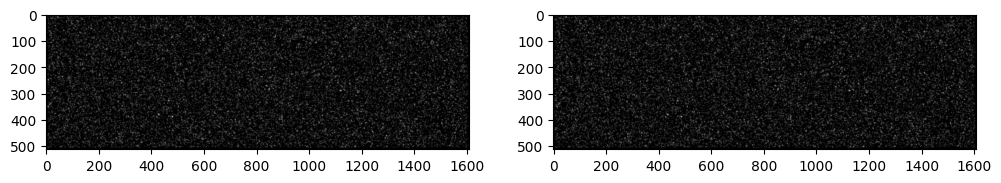

In [3]:
#@title Load the images
# Load the images.
test_dir = tutorial_path + "test0/"
tif_files = glob(os.path.join(test_dir + '*.tiff'))

# Show the images.
frame_a = cv2.imread(tif_files[0], cv2.IMREAD_ANYDEPTH)
frame_b = cv2.imread(tif_files[1], cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 100
ht, wd = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, 2 * tick_step))
    ax.set_yticks(range(0, ht, tick_step))

plt.show()

In [4]:
#@title Geometric settings
#@markdown The shape of the images is `(512, 1608)`.
frame_shape = (512, 1608) #@param {type:"raw"}
particle_method = "agt" #@param ["log", "agt"] {type:"string"}
subpixel_method = "gaussian" #@param ["gaussian", "centroid", "parabolic"] {type:"string"}
threshold = -3 #@param {type:"raw"}
particle_size = 1 #@param {type:"slider", min:1, max:4, step:1}

In [5]:
#@title Relaxation settings
search_size = 20 #@param [16, 20, 24] {type:"raw"}
cluster_size = 20 #@param [16, 20, 24] {type:"raw"}
kernel_size = 64 #@param [32, 64, 128] {type:"raw"}
num_relaxation_iters = 20 #@param {type:"raw"}
relaxation_constant = 3 #@param {type:"slider", min:1, max:5, step:1}
relaxation_method = "bidirectional" #@param ["unidirectional", "bidirectional"] {type:"string"}

In [6]:
#@title Validation settings
#@markdown The median-absolute-deviation (MAD) validation is used here.
num_validation_iters = 5 #@param {type:"raw"}
validation_size = 20 #@param [16, 20, 24] {type:"raw"}
max_validation_size = 8 #@param {type:"raw"}
mad_tol = 2 #@param {type:"slider", min:1, max:4, step:0.5}
epsilon = 0.5 #@param {type:"slider", min:0, max:1, step:0.1}

In [7]:
#@title Perform PTV processing
#@markdown Run this block to process the images.
# Initialize the process.
process = ptv_gpu(frame_shape,
                  particle_method=particle_method,
                  subpixel_method=subpixel_method,
                  threshold=threshold,
                  particle_size=particle_size,
                  search_size=search_size,
                  cluster_size=cluster_size,
                  kernel_size=kernel_size,
                  num_relaxation_iters=num_relaxation_iters,
                  relaxation_constant=relaxation_constant,
                  relaxation_method=relaxation_method,
                  num_validation_iters=num_validation_iters,
                  validation_size=validation_size,
                  max_validation_size=max_validation_size,
                  mad_tol=mad_tol,
                  epsilon=epsilon)

# Process the images.
start_time = time.time()
u, v = process(frame_a, frame_b)

# Get the field coordinates.
x, y = process.coords

# Invert the y axis.
y = frame_shape[0] * process.scaling_par - y
v = -v

# Printout the computation time.
process_time = time.time() - start_time

phi_r = len(u) / len(process.init_coords[0])
print('A total of {} valid matches were identified, yielding a recovery ratio of {}.'.format(len(u), phi_r))
print('Computation time for {} image pair was {:.3f} s.'.format(1, process_time))

A total of 22681 valid matches were identified, yielding a recovery ratio of 1.0.
Computation time for 1 image pair was 10.899 s.


Note that it takes a long time to process the first image on the GPU since CUDA kernels need to be compiled before execution. You may run the above block a second time to see the GPU acceleration. You may also refer to the advanced tutorial to see the performance for a large dataset.

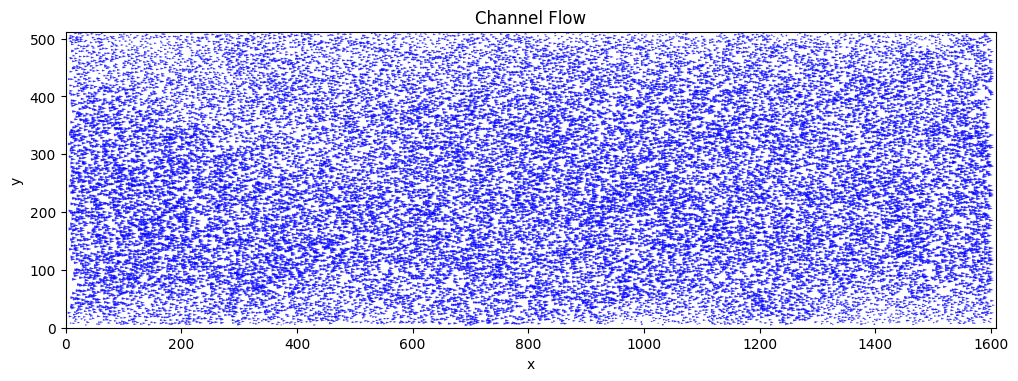

In [8]:
#@title Plot the results
#@markdown Specify the vector scale and width.
vector_width = 0.002 #@param {type:"slider", min:0, max:0.004, step:0.0001}
vector_scale = 0.8 #@param {type:"slider", min:0, max:1, step:0.1}

def plot_vector_field(x, y, u, v, scale=1, width=0.002):
    plt.figure(figsize=(12, 12))
    plt.quiver(x, y, u, v,
               angles='xy', scale_units='xy', scale=scale,
               color='blue', width=width, alpha=0.8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Relaxation-based PTV Matches")
    plt.xlim(0, frame_shape[1])
    plt.ylim(0, frame_shape[0])

    # Force equal aspect ratio, independent of limits
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"Channel Flow")
    plt.show()

plot_vector_field(x, y, u, v, scale=vector_scale, width=vector_width)

## <span style="color:blue;">Vortex Test Case</span>

This section demonstrates the usage of the package for a pair of synthetic images of a strong vortex with variations in seeding concentration and particle image size. The analysis focuses on two distinct cases to illustrate two different particle identification methods.

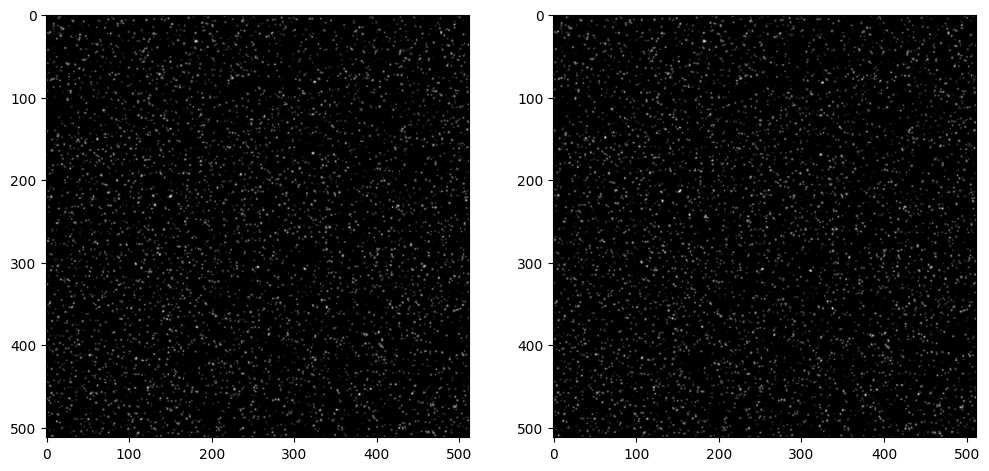

In [9]:
#@title Load the images
# Load the images.
test_dir = tutorial_path + "test1/"

# Show the images.
frame_a = cv2.imread(test_dir + "B005_1" + ".tif", cv2.IMREAD_ANYDEPTH)
frame_b = cv2.imread(test_dir + "B005_2" + ".tif", cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
ticks_step = 100
wd, ht = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, ticks_step))
    ax.set_yticks(range(0, ht, ticks_step))

plt.show()

In [10]:
#@markdown Run this block to perform 2 analysis, using different particle detection methods.
x = []
y = []
u = []
v = []

# Set mandatory settings.
settings = {}
frame_shape = frame_a.shape
settings["subpixel_method"] = "gaussian"
settings["particle_size"] = 1
settings["search_size"] = 20
settings["cluster_size"] = 20
settings["kernel_size"] = 64
settings["num_relaxation_iters"] = 20
settings["relaxation_constant"] = 3
settings["relaxation_method"] = "bidirectional"
settings["num_validation_iters"] = 5
settings["validation_size"] = 20
settings["max_validation_size"] = 8
settings["epsilon"] = 0.5

# Case 1 analysis.
settings["particle_method"] = "agt"
settings["threshold"] = -3
process = ptv_gpu(frame_shape, **settings)
up, vp = process(frame_a, frame_b)
xp, yp = process.coords
x.append(xp)
y.append(yp)
u.append(up)
v.append(vp)

# Case 2 analysis.
settings["particle_method"] = "log"
settings["threshold"] = 0.001
process = ptv_gpu(frame_shape, **settings)
up, vp = process(frame_a, frame_b)
xp, yp = process.coords
x.append(xp)
y.append(yp)
u.append(up)
v.append(vp)

# invert y axis for all.
y = [frame_shape[0] * process.scaling_par - yk for yk in y]
v = [-vk for vk in v]

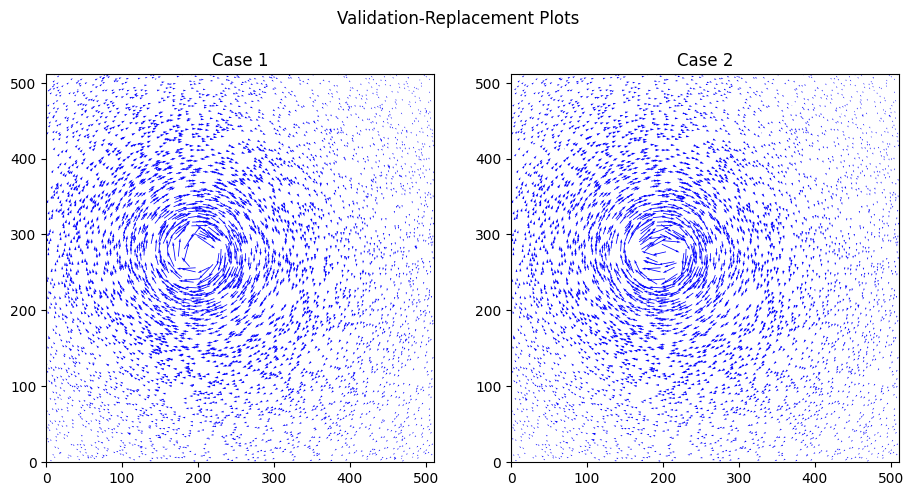

In [11]:
#@title Plot the results
vector_width = 0.002 #@param {type:"slider", min:0, max:0.002, step:0.0001}
vector_scale = 200 #@param {type:"slider", min:10, max:500, step:10}

# Plot the quiver plots.
fig, axs = plt.subplots(1, 2, figsize=(11, 11))
ticks_step = 100
for i, ax in enumerate(axs.flatten()):
    ax.quiver(x[i], y[i], u[i], v[i], color="blue", width=vector_width, scale=vector_scale)

    # Plot settings.
    ax.set_aspect(1)
    ax.set_xlim(x[i].min(), x[i].max())
    ax.set_ylim(y[i].min(), y[i].max())
    ax.set_xticks(range(0, frame_shape[1], ticks_step))
    ax.set_yticks(range(0, frame_shape[0], ticks_step))
    ax.set_title("Case {}".format(i))

# Set titles and labels.
axs[0].set_title('Case 1')
axs[1].set_title('Case 2')

# Adjust spacing between subplots.
fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.suptitle('Validation-Replacement Plots', y=0.73)
plt.show()

The validation method changes along the columns from signal-to-noise ratio to median, while the replacing method changes along the rows from mean to spring analogy. Note how the results change at the center of the vortex where signal-to-noise levels are low.

## <span style="color:blue;">References</span>

> Baek, S. J., & Lee, S. J. (1996). A new two-frame particle tracking algorithm using match probability. Experiments in Fluids, 22(1), 23-32.

> Ohmi, K., & Hang-Yu, L. (2000). Particle-tracking velocimetry with new algorithms. Measurement Science and Technology, 11(6), 603-616.

> Westerweel, J., & Scarano, F. (2005). Universal outlier detection for PIV data. Experiments in fluids, 39(6), 1096-1100.

> Pecora, C. (2018). Particle Tracking Velocimetry: A Review.